# Manifold Learning

## Real-World Scenario: Recovering Cell-Differentiation Trajectories from scRNA-seq

Single-cell RNA-seq experiments capture thousands of cells frozen at random points along a continuous biological process — e.g. a stem cell differentiating into a mature blood cell, or a tumour cell drifting between phenotypic states under drug pressure. Each cell is a vector $\mathbf{x}_n \in \mathbb{R}^D$ with $D$ in the thousands of genes, but the *biology* lives on a low-dimensional **manifold** parameterised by a few latent coordinates (e.g. pseudotime, lineage branch, cycle phase). Linear methods such as PCA project to a flat subspace and miss the curvature; **manifold learning** algorithms learn a faithful low-dimensional embedding $\mathbf{z}_n \in \mathbb{R}^L$ that respects the manifold's intrinsic geometry.

We work through PML §20.4 step by step:

1. **What is a manifold?** (§20.4.1) — tangent spaces, Riemannian structure
2. **The manifold hypothesis** (§20.4.2) — why most natural data lies on one
3. **Approaches** (§20.4.3) — parametric vs. non-parametric, sparse vs. dense
4. **Multi-dimensional scaling** (§20.4.4) — classical, metric, non-metric, Sammon
5. **Isomap** (§20.4.5) — geodesic distances on a kNN graph
6. **Kernel PCA** (§20.4.6) — non-linear PCA via the kernel trick
7. **Maximum variance unfolding** (§20.4.7) — semidefinite programming over distances (sketched)
8. **Local linear embedding** (§20.4.8) — barycentric coordinates from neighbours
9. **Laplacian eigenmaps** (§20.4.9) — spectral embedding via the graph Laplacian
10. **t-SNE and UMAP** (§20.4.10) — probabilistic neighbour matching for visualisation

We ground every method on **two running datasets** taken straight from PML's running examples:

- the **2-d Swiss roll** embedded in 3-d — the canonical curved manifold
- a **scRNA-seq–style 2-d cell-cycle ring** embedded in 64-d gene space — a biotech analogue


In [1]:
import os
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from sklearn.datasets import make_swiss_roll
from sklearn.manifold import MDS, Isomap, LocallyLinearEmbedding, SpectralEmbedding, TSNE
from sklearn.decomposition import KernelPCA
from sklearn.neighbors import kneighbors_graph
from scipy.sparse.csgraph import shortest_path
from scipy.spatial.distance import squareform, pdist

np.random.seed(0)

plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams['font.family'] = 'DejaVu Sans'

print(f'numpy {np.__version__}')

numpy 2.4.3


## 1. What is a Manifold? (§20.4.1)

Roughly: a $d$-dimensional **manifold** is a topological space that *looks Euclidean locally*. The classic example is the surface of the Earth — globally a 2-sphere, but to anyone standing on it the ground feels like a flat plane. Formally, every point $x$ on the manifold $\mathcal{X}$ has a neighbourhood that is topologically equivalent to a $d$-dimensional Euclidean space called the **tangent space** $\mathcal{T}_x \mathcal{X}$.

A **Riemannian manifold** further equips each tangent space with an inner product that varies smoothly with $x$. This induces:

- **distances** along curves (geodesics)
- **angles** between tangent vectors
- **volumes** of subsets

> **Whitney embedding theorem.** Any sufficiently smooth Riemannian $d$-manifold can be embedded into $\mathbb{R}^{2d+1}$ — i.e. you only ever need a *constant* multiple of the intrinsic dimension to host a manifold faithfully. This is exactly the regime manifold-learning algorithms exploit.


## 2. The Manifold Hypothesis (§20.4.2)

> Most "naturally occurring" high-dimensional datasets lie on a low-dimensional manifold.

PML's vignette is striking: a $64\times 57$ image of the digit "6" is a vector in $\mathbb{R}^{3648}$. Drawing a vector uniformly from $\{0,1\}^{3648}$ basically never produces a digit — the set of digit images is a tiny, curved subset of pixel space. If we generate variations by *rotating* a single 6 through 360°, the dataset traces out a **2-d circular manifold** embedded in $\mathbb{R}^{3648}$.

We can demo the same effect on a much smaller scale: build a 64-d "gene-expression" version of a single cell-cycle ring and look at where it sits in PCA coordinates.

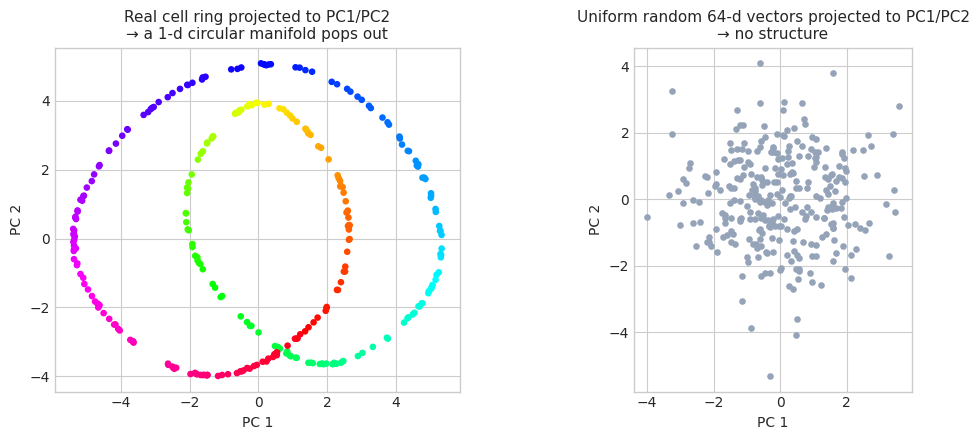

In [2]:
def make_cell_ring(N=300, D=64, noise=0.02, seed=0):
    rng = np.random.default_rng(seed)
    theta = rng.uniform(0, 2 * np.pi, N)
    a = np.stack([np.cos(theta), np.sin(theta), np.sin(2 * theta), np.cos(2 * theta)], axis=1)
    W = rng.standard_normal((D, 4))
    X = np.tanh(a @ W.T) + noise * rng.standard_normal((N, D))
    return X.astype(np.float32), theta.astype(np.float32)

X_ring, theta_ring = make_cell_ring(N=300, D=64, seed=0)

# A single random vector in [0,1]^64 — the "scrambled image" analogue
rng = np.random.default_rng(7)
X_random = rng.standard_normal((300, 64))

def pca_2d(X):
    Xc = X - X.mean(0)
    _, _, Vt = np.linalg.svd(Xc, full_matrices=False)
    return Xc @ Vt[:2].T

Z_ring = pca_2d(X_ring)
Z_rand = pca_2d(X_random)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].scatter(Z_ring[:, 0], Z_ring[:, 1], c=theta_ring, cmap='hsv', s=14)
axes[0].set_title('Real cell ring projected to PC1/PC2\n→ a 1-d circular manifold pops out', fontsize=11)
axes[0].set_aspect('equal'); axes[0].set_xlabel('PC 1'); axes[0].set_ylabel('PC 2')

axes[1].scatter(Z_rand[:, 0], Z_rand[:, 1], color='#94a3b8', s=14)
axes[1].set_title('Uniform random 64-d vectors projected to PC1/PC2\n→ no structure', fontsize=11)
axes[1].set_aspect('equal'); axes[1].set_xlabel('PC 1'); axes[1].set_ylabel('PC 2')
plt.tight_layout(); plt.show()

**Take-away.** The cell-ring data has **intrinsic dimension** $d = 1$ (the angle $\theta$) but lives in **ambient dimension** $D = 64$. The job of manifold learning is to recover $\mathbf{z}_n = \theta_n$ from $\mathbf{x}_n$ alone.

## 3. Approaches to Manifold Learning (§20.4.3)

PML groups the methods by three orthogonal properties:

| Method                 | Parametric? | Convex?       | Section |
|------------------------|-------------|---------------|---------|
| PCA / classical MDS    | No          | Yes (dense)   | §20.1   |
| Kernel PCA             | No          | Yes (dense)   | §20.4.6 |
| Isomap                 | No          | Yes (dense)   | §20.4.5 |
| LLE                    | No          | Yes (sparse)  | §20.4.8 |
| Laplacian eigenmaps    | No          | Yes (sparse)  | §20.4.9 |
| t-SNE / UMAP           | No          | **No**        | §20.4.10|
| Autoencoder            | **Yes**     | No            | §20.3   |

- **Non-parametric** methods learn an embedding $\mathbf{z}_i$ for each *training* point but no general $\mathbf{x} \mapsto \mathbf{z}$ mapping — adding a new point requires re-fitting (no out-of-sample generalisation).
- **Convex / dense**: solve a single eigendecomposition of an $N\times N$ matrix.
- **Convex / sparse**: solve a sparse generalised eigenproblem — much cheaper for large $N$.
- **Non-convex**: gradient-based optimisation (t-SNE, autoencoders).

We now build the running datasets and apply each method in turn.

### Running Datasets

Following PML, we use the **2-d Swiss roll embedded in 3-d** plus a **cell-cycle ring embedded in 64-d gene space**. Both have known intrinsic dimensionality (2 and 1 respectively), so we can colour points by their true latent coordinate and visually grade each method's faithfulness.

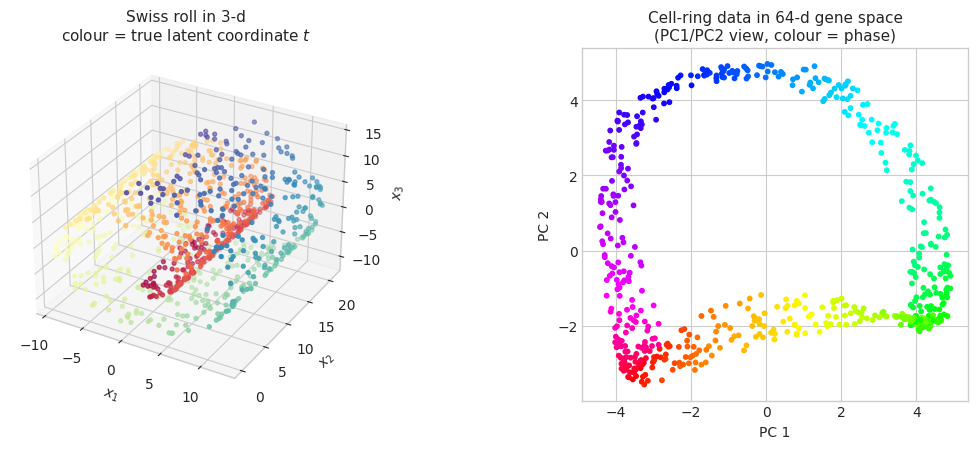

In [3]:
# 1. Swiss roll
X_swiss, t_swiss = make_swiss_roll(n_samples=1000, noise=0.0, random_state=0)

# 2. Cell-cycle ring in 64-d gene space (with thickness so it's 2-d)
def make_cell_ring_2d(N=600, D=64, noise=0.04, seed=1):
    rng = np.random.default_rng(seed)
    theta = rng.uniform(0, 2 * np.pi, N)
    r = rng.uniform(0.7, 1.3, N)            # radial thickness — the second latent dim
    a = np.stack([
        r * np.cos(theta),
        r * np.sin(theta),
        r,
        np.sin(2 * theta),
    ], axis=1)
    W = rng.standard_normal((D, 4))
    X = np.tanh(a @ W.T) + noise * rng.standard_normal((N, D))
    return X.astype(np.float32), theta.astype(np.float32), r.astype(np.float32)

X_cell, theta_cell, r_cell = make_cell_ring_2d(N=600, D=64, seed=1)

fig = plt.figure(figsize=(12, 4.6))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.scatter(X_swiss[:, 0], X_swiss[:, 1], X_swiss[:, 2], c=t_swiss, cmap='Spectral', s=8)
ax1.set_title('Swiss roll in 3-d\ncolour = true latent coordinate $t$', fontsize=11)
ax1.set_xlabel('$x_1$'); ax1.set_ylabel('$x_2$'); ax1.set_zlabel('$x_3$')

ax2 = fig.add_subplot(1, 2, 2)
Z = pca_2d(X_cell)
ax2.scatter(Z[:, 0], Z[:, 1], c=theta_cell, cmap='hsv', s=10)
ax2.set_title('Cell-ring data in 64-d gene space\n(PC1/PC2 view, colour = phase)', fontsize=11)
ax2.set_aspect('equal'); ax2.set_xlabel('PC 1'); ax2.set_ylabel('PC 2')
plt.tight_layout(); plt.show()

## 4. Multi-dimensional Scaling (MDS) (§20.4.4)

MDS finds an embedding $\{\mathbf{z}_i\}$ whose pairwise distances best match a given dissimilarity matrix $\mathbf{D} = \{d_{ij}\}$. There are several flavours.

### 4.1 Classical MDS (§20.4.4.1)

Build the centred Gram matrix from raw features:

$$\tilde K_{ij} = \langle \mathbf{x}_i - \bar{\mathbf{x}},\, \mathbf{x}_j - \bar{\mathbf{x}} \rangle, \qquad \tilde{\mathbf{K}} = \tilde{\mathbf{X}} \tilde{\mathbf{X}}^\top.$$

Define the **strain** loss

$$\mathcal{L}_{\text{strain}}(\mathbf{Z}) = \sum_{ij} (\tilde K_{ij} - \langle \tilde{\mathbf{z}}_i, \tilde{\mathbf{z}}_j\rangle)^2 = \|\tilde{\mathbf{K}} - \tilde{\mathbf{Z}}\tilde{\mathbf{Z}}^\top\|_F^2.$$

The minimiser is given by the rank-$L$ truncated SVD: $\tilde{\mathbf{K}} = \mathbf{U}\mathbf{S}\mathbf{V}^\top$, embeddings $\tilde{\mathbf{Z}} = \mathbf{U} \mathbf{S}^{1/2}$. Equation (20.110) shows that this is **identical to PCA** — they recover the same subspace.

If we only have a Euclidean distance matrix $\mathbf{D}$, we double-centre $\mathbf{D}^{(2)} = \mathbf{D} \odot \mathbf{D}$ to recover $\tilde{\mathbf{K}}$:

$$\tilde K_{ij} = -\tfrac{1}{2}\!\left( d_{ij}^2 - \tfrac{1}{N}\sum_l d_{il}^2 - \tfrac{1}{N}\sum_l d_{jl}^2 + \tfrac{1}{N^2}\sum_{lm} d_{lm}^2 \right).$$

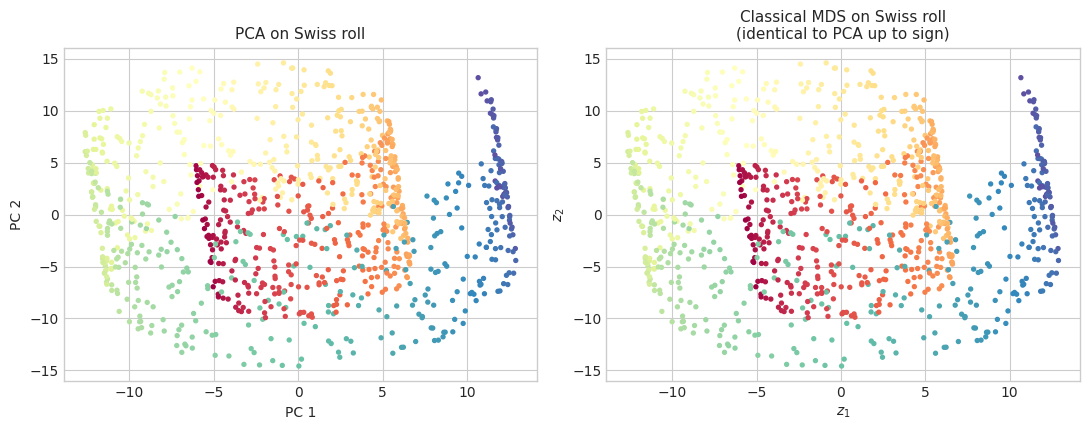

PCA vs classical-MDS embedding (post-Procrustes) : max abs diff = 1.04e-13


In [4]:
def classical_mds(D2, L=2):
    # D2 = squared distance matrix
    N = D2.shape[0]
    H = np.eye(N) - np.ones((N, N)) / N        # centering matrix C_N
    K = -0.5 * H @ D2 @ H                      # double-centred Gram matrix
    evals, evecs = np.linalg.eigh(K)
    idx = np.argsort(evals)[::-1][:L]
    return evecs[:, idx] * np.sqrt(np.maximum(evals[idx], 0))

# Distance matrix for Swiss roll (Euclidean in ambient space)
D_swiss = squareform(pdist(X_swiss))
Z_classical = classical_mds(D_swiss ** 2, L=2)

# Compare to PCA
Z_pca = pca_2d(X_swiss)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
axes[0].scatter(Z_pca[:, 0], Z_pca[:, 1], c=t_swiss, cmap='Spectral', s=8)
axes[0].set_title('PCA on Swiss roll', fontsize=11)
axes[0].set_xlabel('PC 1'); axes[0].set_ylabel('PC 2')

axes[1].scatter(Z_classical[:, 0], Z_classical[:, 1], c=t_swiss, cmap='Spectral', s=8)
axes[1].set_title('Classical MDS on Swiss roll\n(identical to PCA up to sign)', fontsize=11)
axes[1].set_xlabel('$z_1$'); axes[1].set_ylabel('$z_2$')
plt.tight_layout(); plt.show()

# Verify: Procrustes-aligned residual is essentially zero
def proc_align(A, B):
    Ac = A - A.mean(0); Bc = B - B.mean(0)
    U, _, Vt = np.linalg.svd(Bc.T @ Ac)
    R = (U @ Vt).T
    return Ac, Bc @ R

Ac, Bc = proc_align(Z_pca, Z_classical)
print(f'PCA vs classical-MDS embedding (post-Procrustes) : max abs diff = {np.abs(Ac - Bc).max():.2e}')

**Failure mode.** Classical MDS / PCA flatten the Swiss roll the wrong way — they preserve *ambient* Euclidean distances, but two points on opposite ends of the unrolled spiral are close in 3-d while being far apart along the manifold. The colour gradient is scrambled.

### 4.2 Metric MDS (§20.4.4.2)

Allow any dissimilarity, not just Euclidean. Minimise the **stress**:

$$\mathcal{L}_{\text{stress}}(\mathbf{Z}) = \sqrt{\frac{\sum_{i<j} (d_{ij} - \hat d_{ij})^2}{\sum_{ij} d_{ij}^2}}, \qquad \hat d_{ij} = \|\mathbf{z}_i - \mathbf{z}_j\|.$$

Solved with the **SMACOF** (Scaling by MAjorising a COmplication Function) bound-optimisation algorithm — that's what `sklearn.manifold.MDS` uses.

### 4.3 Non-metric MDS (§20.4.4.3)

Match the *ranking* of distances rather than their magnitudes. Let $f$ be a monotonic transformation; minimise

$$\mathcal{L}_{\text{NM}}(\mathbf{Z}) = \sqrt{\frac{\sum_{i<j} (f(d_{ij}) - \hat d_{ij})^2}{\sum_{ij} \hat d_{ij}^2}}.$$

Useful when only ordinal similarity is meaningful (e.g. survey ranking).

### 4.4 Sammon mapping (§20.4.4.4)

Reweight stress so small distances dominate — preserve local structure:

$$\mathcal{L}_{\text{Sammon}}(\mathbf{Z}) = \frac{1}{\sum_{i<j} d_{ij}} \sum_{i \ne j} \frac{(\hat d_{ij} - d_{ij})^2}{d_{ij}}.$$

Non-convex, but the local emphasis is what later methods (Isomap, LLE) build on.

/Users/christophe/Sites/notebook/venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/Users/christophe/Sites/notebook/venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


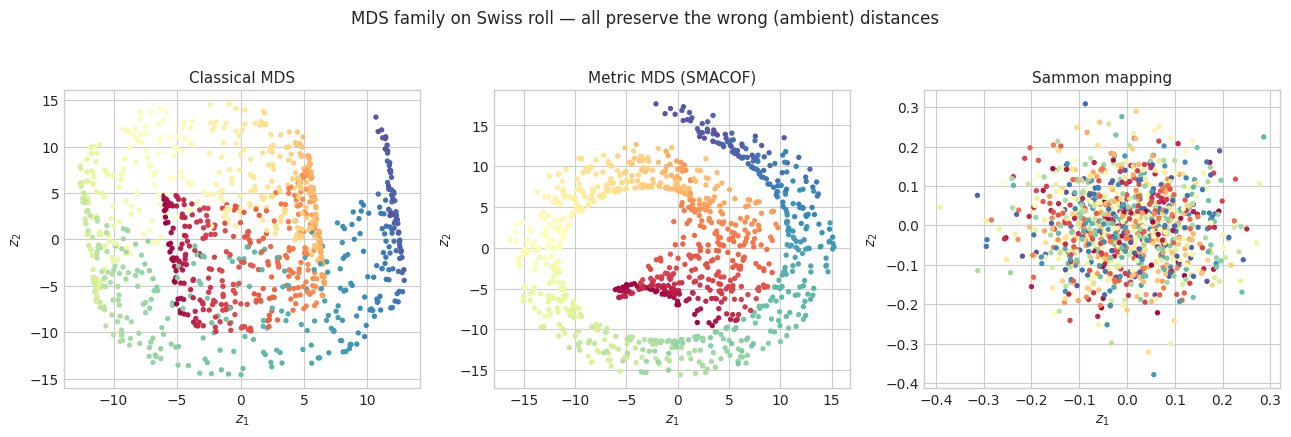

In [5]:
# Metric MDS (sklearn) and a tiny Sammon-mapping implementation
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=0,
          n_init=1, max_iter=300, normalized_stress='auto')
Z_metric = mds.fit_transform(D_swiss)

def sammon(D, L=2, n_iter=200, lr=0.3, seed=0):
    rng = np.random.default_rng(seed)
    N = D.shape[0]
    Z = rng.standard_normal((N, L)) * 0.1
    eps = 1e-9
    iu = np.triu_indices(N, k=1)
    D_off = D[iu]
    c = D_off.sum() + eps
    for _ in range(n_iter):
        diff = Z[:, None, :] - Z[None, :, :]
        Dz = np.linalg.norm(diff, axis=-1) + eps
        # gradient of Sammon stress wrt z_i
        coef = (D - Dz) / (D * Dz + eps)
        np.fill_diagonal(coef, 0.0)
        grad = -2 / c * (coef[:, :, None] * diff).sum(axis=1)
        Z = Z - lr * grad
    return Z

Z_sammon = sammon(D_swiss, L=2, n_iter=150, lr=0.05, seed=0)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, Z, title in zip(axes,
                        [Z_classical, Z_metric, Z_sammon],
                        ['Classical MDS', 'Metric MDS (SMACOF)', 'Sammon mapping']):
    ax.scatter(Z[:, 0], Z[:, 1], c=t_swiss, cmap='Spectral', s=8)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('$z_1$'); ax.set_ylabel('$z_2$')
plt.suptitle('MDS family on Swiss roll — all preserve the wrong (ambient) distances',
             fontsize=12, y=1.03)
plt.tight_layout(); plt.show()

All three MDS variants suffer the same flaw: they treat the 3-d ambient Euclidean distance as ground truth. To "unroll" the Swiss roll we need **geodesic** distances — that's what Isomap does next.

## 5. Isomap (§20.4.5)

Isomap fixes MDS by replacing ambient distance with **geodesic distance along a kNN graph**:

1. Build the **$K$-nearest-neighbour graph** of the data, with edge weights $\|\mathbf{x}_i - \mathbf{x}_j\|$.
2. Compute all-pairs **shortest paths** (Dijkstra) — this approximates the manifold geodesic.
3. Apply **classical MDS** to the resulting distance matrix.

Two points on opposite ends of the spiral are now *graph-distant* (you have to walk all the way along the roll to get from one to the other), so MDS will faithfully unroll the manifold.

### Failure mode: short-circuits

If the data is noisy and a kNN edge accidentally connects two faraway sheets of the manifold, the shortest path "shortcuts" through that edge, distorting the embedding. PML calls this **topological instability** — we'll demo it explicitly below.

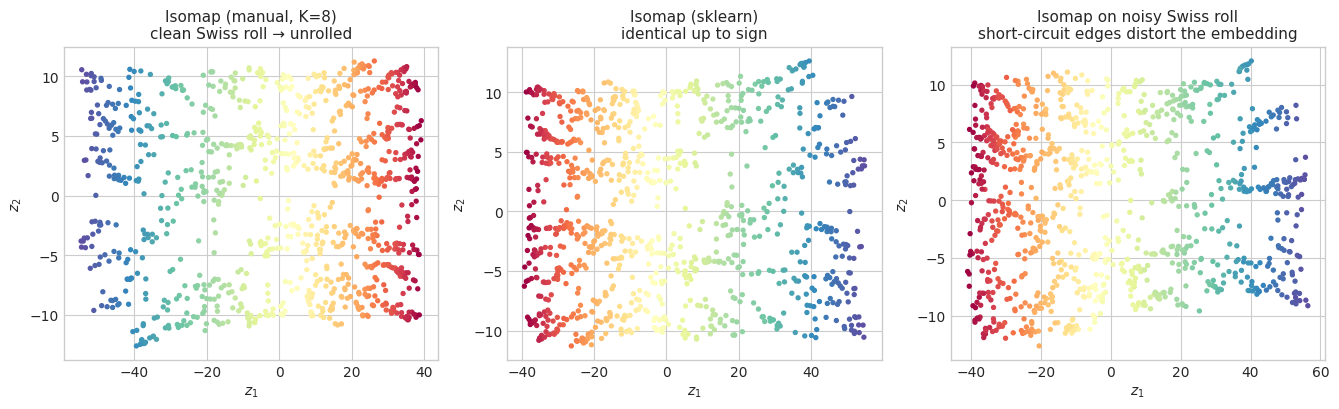

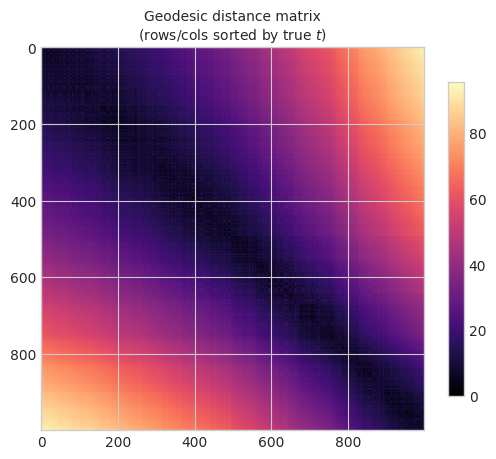

In [6]:
# 1. Manual Isomap on Swiss roll, K = 8
def isomap_manual(X, K=8, L=2):
    G = kneighbors_graph(X, n_neighbors=K, mode='distance', include_self=False)
    G = G.maximum(G.T)                                  # symmetrise the kNN graph
    d_geo = shortest_path(G, method='D', directed=False)
    if not np.all(np.isfinite(d_geo)):
        # fall back to a finite large constant for unreachable pairs
        d_geo = np.where(np.isfinite(d_geo), d_geo, d_geo[np.isfinite(d_geo)].max() * 2)
    return classical_mds(d_geo ** 2, L=L), d_geo

Z_iso, d_geo = isomap_manual(X_swiss, K=8, L=2)

# 2. Sklearn Isomap for sanity
iso = Isomap(n_neighbors=8, n_components=2)
Z_iso_sk = iso.fit_transform(X_swiss)

# 3. Noisy Swiss roll → demo of short-circuit failure
X_noisy, t_noisy = make_swiss_roll(n_samples=1000, noise=0.5, random_state=0)
Z_noisy_iso, _ = isomap_manual(X_noisy, K=8, L=2)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))
axes[0].scatter(Z_iso[:, 0], Z_iso[:, 1], c=t_swiss, cmap='Spectral', s=8)
axes[0].set_title('Isomap (manual, K=8)\nclean Swiss roll → unrolled', fontsize=11)
axes[0].set_xlabel('$z_1$'); axes[0].set_ylabel('$z_2$')

axes[1].scatter(Z_iso_sk[:, 0], Z_iso_sk[:, 1], c=t_swiss, cmap='Spectral', s=8)
axes[1].set_title('Isomap (sklearn)\nidentical up to sign', fontsize=11)
axes[1].set_xlabel('$z_1$'); axes[1].set_ylabel('$z_2$')

axes[2].scatter(Z_noisy_iso[:, 0], Z_noisy_iso[:, 1], c=t_noisy, cmap='Spectral', s=8)
axes[2].set_title('Isomap on noisy Swiss roll\nshort-circuit edges distort the embedding',
                  fontsize=11)
axes[2].set_xlabel('$z_1$'); axes[2].set_ylabel('$z_2$')
plt.tight_layout(); plt.show()

# Inspect the geodesic distance matrix
fig, ax = plt.subplots(figsize=(5.4, 4.6))
order = np.argsort(t_swiss)                # sort by true latent for a tidy block structure
im = ax.imshow(d_geo[order][:, order], cmap='magma')
ax.set_title('Geodesic distance matrix\n(rows/cols sorted by true $t$)', fontsize=10)
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()

## 6. Kernel PCA (§20.4.6)

Kernel PCA replaces the Gram matrix $\mathbf{K} = \mathbf{X}\mathbf{X}^\top$ in classical MDS / PCA with a kernel evaluation:

$$K_{ij} = \mathcal{K}(\mathbf{x}_i, \mathbf{x}_j),$$

then double-centres and eigendecomposes. The eigenvectors (scaled by $\sqrt{\lambda}$) are the kPCA embeddings:

$$\mathbf{V}_{\text{kPCA}} = \mathbf{\Phi}^\top \mathbf{U} \boldsymbol\Lambda^{-1/2}.$$

For the projection of a *test* point we use

$$\boldsymbol\phi_*^\top \mathbf{V}_{\text{kPCA}} = \mathbf{k}_*^\top \mathbf{U} \boldsymbol\Lambda^{-1/2}, \qquad k_{*,i} = \mathcal{K}(\mathbf{x}_*, \mathbf{x}_i).$$

**Centring in feature space** is non-trivial because $\boldsymbol\phi(\mathbf{x})$ may be infinite-dim; the trick (Eq. 7.89) is

$$\tilde{\mathbf{K}} = \mathbf{C}_N \mathbf{K} \mathbf{C}_N, \qquad \mathbf{C}_N = \mathbf{I}_N - \tfrac{1}{N}\mathbf{1}_N \mathbf{1}_N^\top.$$

PML notes that **kPCA with an RBF kernel actually *expands* the feature space** rather than compressing it (it's effectively a similarity-preserving lift) — so its top components are not always useful for unrolling a manifold. The next section, MVU, addresses this directly.

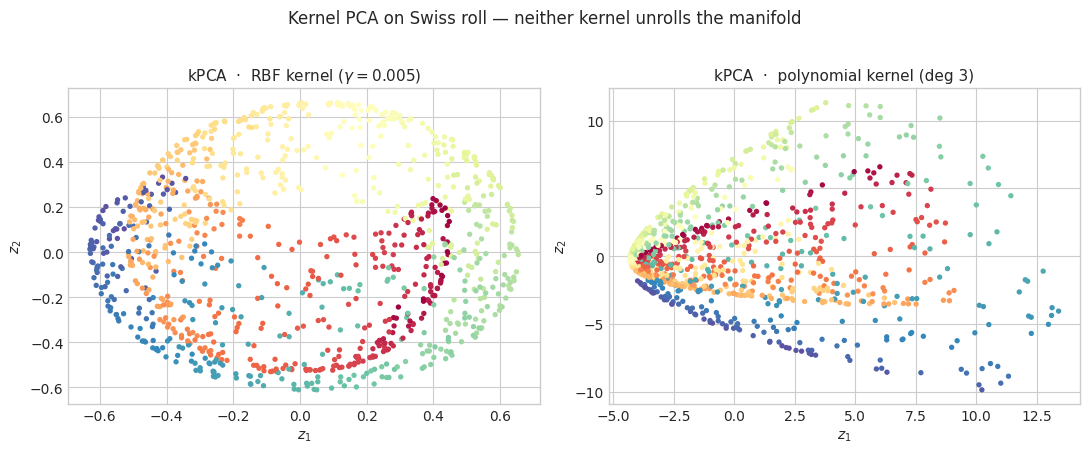

In [7]:
# kPCA on Swiss roll with two kernel choices
kpca_rbf  = KernelPCA(n_components=2, kernel='rbf',  gamma=0.005)
kpca_poly = KernelPCA(n_components=2, kernel='poly', degree=3, gamma=0.01)

Z_rbf  = kpca_rbf.fit_transform(X_swiss)
Z_poly = kpca_poly.fit_transform(X_swiss)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, Z, title in zip(axes,
                        [Z_rbf, Z_poly],
                        ['kPCA  ·  RBF kernel ($\\gamma=0.005$)',
                         'kPCA  ·  polynomial kernel (deg 3)']):
    ax.scatter(Z[:, 0], Z[:, 1], c=t_swiss, cmap='Spectral', s=8)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('$z_1$'); ax.set_ylabel('$z_2$')
plt.suptitle('Kernel PCA on Swiss roll — neither kernel unrolls the manifold',
             fontsize=12, y=1.02)
plt.tight_layout(); plt.show()

**Take-away.** Off-the-shelf RBF / polynomial kPCA gives interesting non-linear projections but does *not* recover the Swiss roll geometry. We get curved blobs because RBF distances saturate before they ever resemble manifold geodesics.

## 7. Maximum Variance Unfolding (§20.4.7)

MVU (a.k.a. **semidefinite embedding**) tries to *maximise* the variance of the embedding while preserving every kNN distance:

$$\max \sum_{ij} \|\mathbf{z}_i - \mathbf{z}_j\|^2 \quad\text{s.t.}\quad \|\mathbf{z}_i - \mathbf{z}_j\|^2 = \|\mathbf{x}_i - \mathbf{x}_j\|^2 \;\;\forall (i,j) \in G,$$

where $G$ is the kNN graph. Recast as a **semidefinite program** in the kernel matrix $\mathbf{K} = \mathbf{Z}\mathbf{Z}^\top$:

$$\max \operatorname{tr}(\mathbf{K}) \quad\text{s.t.}\quad \|\mathbf{z}_i-\mathbf{z}_j\|^2 = \|\mathbf{x}_i-\mathbf{x}_j\|^2,\;\; \sum_{ij} K_{ij} = 0,\;\; \mathbf{K}\succeq 0.$$

Then run kPCA on the optimised $\mathbf{K}$. We don't run an SDP solver here (CVX would scale to ~100s of points only); the take-away is that MVU is the *principled* fix for kPCA — let the data tell you the right kernel by demanding that the kNN distances be Euclidean.

## 8. Local Linear Embedding (LLE) (§20.4.8)

LLE keeps things **local**:

1. Approximate each $\mathbf{x}_i$ as a linear combination of its $K$ nearest neighbours,

   $$\hat{\mathbf{W}} = \arg\min_{\mathbf{W}} \sum_i \!\Big\| \mathbf{x}_i - \sum_j w_{ij} \mathbf{x}_j \Big\|^2 \quad\text{s.t.}\quad w_{ij}=0\text{ if }j\notin\mathrm{nbr}(i,K),\;\; \sum_j w_{ij}=1.$$

   The optimal weights $\mathbf{w}_{i,:}$ are the **barycentric coordinates** of $\mathbf{x}_i$ in its neighbourhood — they capture the *local geometry* and are invariant to rotation, translation, and rescaling.

2. Find low-dim embeddings that preserve those same weights:

   $$\hat{\mathbf{Z}} = \arg\min_{\mathbf{Z}} \sum_i \!\Big\| \mathbf{z}_i - \sum_j \hat w_{ij} \mathbf{z}_j \Big\|^2 = \mathbf{Z}^\top (\mathbf{I} - \hat{\mathbf{W}})^\top (\mathbf{I} - \hat{\mathbf{W}}) \mathbf{Z}.$$

   The solution: bottom $L$ non-trivial eigenvectors of $(\mathbf{I} - \hat{\mathbf{W}})^\top (\mathbf{I} - \hat{\mathbf{W}})$ — a **sparse** eigenproblem because each row of $\mathbf{W}$ has only $K$ non-zeros.

LLE is more robust to short-circuit noise than Isomap because no single edge can warp the global geometry.

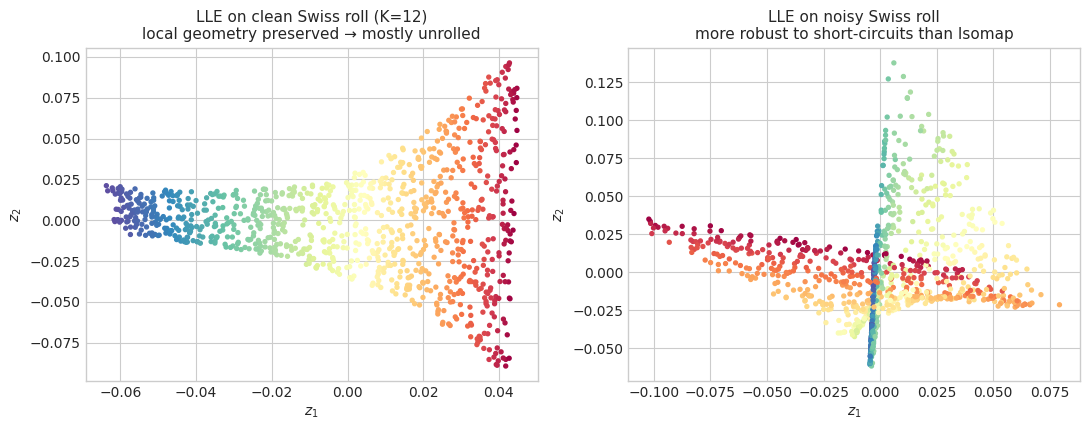

In [8]:
lle = LocallyLinearEmbedding(n_neighbors=12, n_components=2, random_state=0, method='standard')
Z_lle = lle.fit_transform(X_swiss)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
axes[0].scatter(Z_lle[:, 0], Z_lle[:, 1], c=t_swiss, cmap='Spectral', s=8)
axes[0].set_title('LLE on clean Swiss roll (K=12)\nlocal geometry preserved → mostly unrolled',
                  fontsize=11)
axes[0].set_xlabel('$z_1$'); axes[0].set_ylabel('$z_2$')

# Robustness to noise
Z_lle_noisy = LocallyLinearEmbedding(n_neighbors=12, n_components=2, random_state=0,
                                     method='standard').fit_transform(X_noisy)
axes[1].scatter(Z_lle_noisy[:, 0], Z_lle_noisy[:, 1], c=t_noisy, cmap='Spectral', s=8)
axes[1].set_title('LLE on noisy Swiss roll\nmore robust to short-circuits than Isomap',
                  fontsize=11)
axes[1].set_xlabel('$z_1$'); axes[1].set_ylabel('$z_2$')
plt.tight_layout(); plt.show()

## 9. Laplacian Eigenmaps (§20.4.9)

Find embeddings that are **smooth on the kNN graph** — points that are graph-neighbours should land close in the embedding. Define edge weights

$$W_{ij} = \exp\!\left(-\frac{\|\mathbf{x}_i - \mathbf{x}_j\|^2}{2\sigma^2}\right) \text{ if } j \in \mathrm{nbr}(i),\;\; 0 \text{ otherwise}.$$

Minimise

$$\mathcal{L}(\mathbf{Z}) = \sum_{(i,j)\in E} W_{ij} \|\mathbf{z}_i - \mathbf{z}_j\|^2 = 2\,\mathrm{tr}(\mathbf{Z}^\top \mathbf{L}\mathbf{Z}), \qquad \mathbf{L} = \mathbf{D} - \mathbf{W},$$

subject to $\mathbf{Z}^\top \mathbf{D}\mathbf{Z} = \mathbf{I}$ (to avoid the trivial $\mathbf{Z}=\mathbf{0}$). The minimiser is the bottom-$L$ non-trivial eigenvectors of the **generalised eigenproblem** $\mathbf{L}\mathbf{z} = \lambda \mathbf{D}\mathbf{z}$.

### 9.1 What is the graph Laplacian? (§20.4.9.2)

Given a weighted graph with adjacency $\mathbf{W}$ and diagonal degree $\mathbf{D} = \mathrm{diag}(d_i)$ where $d_i = \sum_j w_{ij}$:

$$\mathbf{L} = \mathbf{D} - \mathbf{W} \;\;\Leftrightarrow\;\; L_{ij} = \begin{cases} d_i & i = j \\ -w_{ij} & i \ne j, w_{ij} \ne 0 \\ 0 & \text{otherwise} \end{cases}$$

For any function $f : V \to \mathbb{R}$ on the nodes, $\mathbf{L}$ acts as a **discrete derivative operator**:

$$(\mathbf{L} f)(i) = \sum_{j \in \mathrm{nbr}(i)} w_{ij} \big(f(i) - f(j)\big).$$

The **Dirichlet energy** measures the smoothness of $f$:

$$f^\top \mathbf{L} f = \tfrac{1}{2} \sum_{i,j} w_{ij} (f_i - f_j)^2 \;\geq\; 0,$$

so $\mathbf{L}$ is positive semi-definite. Its eigenvectors form a **basis of orthogonal smooth functions** on the graph in increasing order of roughness — the very basis the eigenmap uses to embed.

In [9]:
# Visualise the graph Laplacian on a tiny example
def build_W(coords, sigma=1.0, K=3):
    G = kneighbors_graph(coords, n_neighbors=K, mode='distance', include_self=False).toarray()
    G = np.maximum(G, G.T)
    W = np.where(G > 0, np.exp(-G ** 2 / (2 * sigma ** 2)), 0.0)
    return W

# 6-node toy graph from PML Fig. 20.39 (approximate layout)
coords = np.array([[0, 0], [1, 0], [2, 0], [0.5, 1], [1.5, 1], [2.5, 1]], float)
W_toy = (build_W(coords, sigma=1.0, K=2) > 0).astype(float)
D_toy = np.diag(W_toy.sum(1))
L_toy = D_toy - W_toy
print('W (adjacency):'); print(W_toy.astype(int))
print('\nD (degree):'); print(np.diag(D_toy).astype(int))
print('\nL = D - W:'); print(L_toy.astype(int))
print(f'\neigenvalues of L: {np.round(np.linalg.eigvalsh(L_toy), 3)}')
print('(first eigenvalue is 0 — corresponds to the constant vector — and the count of')
print(' zero eigenvalues equals the number of connected components.)')

W (adjacency):
[[0 1 0 1 0 0]
 [1 0 1 1 0 0]
 [0 1 0 0 1 1]
 [1 1 0 0 1 0]
 [0 0 1 1 0 1]
 [0 0 1 0 1 0]]

D (degree):
[2 3 3 3 3 2]

L = D - W:
[[ 2 -1  0 -1  0  0]
 [-1  3 -1 -1  0  0]
 [ 0 -1  3  0 -1 -1]
 [-1 -1  0  3 -1  0]
 [ 0  0 -1 -1  3 -1]
 [ 0  0 -1  0 -1  2]]

eigenvalues of L: [-0.  1.  3.  3.  4.  5.]
(first eigenvalue is 0 — corresponds to the constant vector — and the count of
 zero eigenvalues equals the number of connected components.)


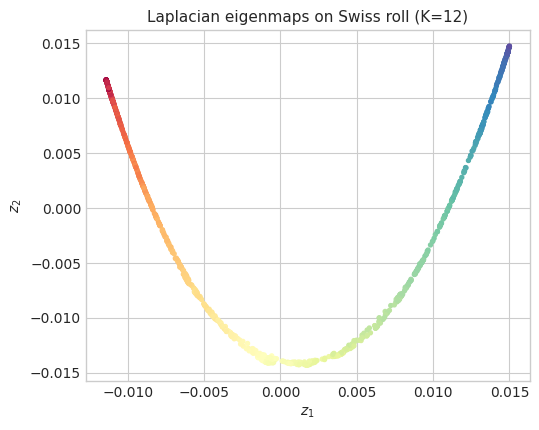

In [10]:
# Laplacian eigenmaps on Swiss roll
le = SpectralEmbedding(n_neighbors=12, n_components=2, random_state=0,
                       affinity='nearest_neighbors')
Z_le = le.fit_transform(X_swiss)

fig, ax = plt.subplots(figsize=(5.5, 4.4))
ax.scatter(Z_le[:, 0], Z_le[:, 1], c=t_swiss, cmap='Spectral', s=8)
ax.set_title('Laplacian eigenmaps on Swiss roll (K=12)', fontsize=11)
ax.set_xlabel('$z_1$'); ax.set_ylabel('$z_2$')
plt.tight_layout(); plt.show()

## 10. t-SNE (§20.4.10)

t-SNE turns distances into **probabilities** and matches them across spaces.

### 10.1 SNE (§20.4.10.1)

In high-dim, define a directional similarity from $i$ to $j$:

$$p_{j|i} = \frac{\exp\!\big(-\tfrac{1}{2\sigma_i^2}\|\mathbf{x}_i - \mathbf{x}_j\|^2\big)}{\sum_{k\neq i}\exp\!\big(-\tfrac{1}{2\sigma_i^2}\|\mathbf{x}_i - \mathbf{x}_k\|^2\big)},$$

with a per-point bandwidth $\sigma_i$. In low-dim, define the analogue $q_{j|i}$ with $\sigma=1$. Minimise

$$\mathcal{L} = \sum_i D_{\mathrm{KL}}(P_i \,\|\, Q_i) = \sum_i \sum_j p_{j|i} \log \frac{p_{j|i}}{q_{j|i}}.$$

Asymmetric: pulling distant points apart is cheap, pulling nearby points apart is expensive.

### 10.2 Symmetric SNE (§20.4.10.2)

Use a **single joint** distribution $p_{ij}$ and minimise $D_{\mathrm{KL}}(P\,\|\,Q)$. Easier; loses some properties of the asymmetric version.

### 10.3 t-distributed SNE (§20.4.10.3)

Replace the Gaussian similarity in low-dim with a **Cauchy** (Student-$t$ with $\nu=1$):

$$q_{ij} = \frac{(1 + \|\mathbf{z}_i-\mathbf{z}_j\|^2)^{-1}}{\sum_{k<l}(1 + \|\mathbf{z}_k-\mathbf{z}_l\|^2)^{-1}}.$$

The heavy tail eliminates spurious attraction between *moderately* distant points — the **crowding problem**. t-SNE clusters look "starry": well-separated galaxies of dense neighbourhoods.

### 10.4 Choosing the length scale (§20.4.10.4)

$\sigma_i$ is set so that $P_i$ has a user-specified **perplexity**:

$$\mathrm{perp}(P_i) = 2^{H(P_i)}, \qquad H(P_i) = -\sum_j p_{j|i} \log_2 p_{j|i}.$$

Loosely, perplexity is the "effective number of neighbours" each point sees. Typical values: 5–50. Different perplexities can give wildly different t-SNE plots — always run with several values.

### 10.5 Computational issues (§20.4.10.5)

Naive cost is $O(N^2)$ per gradient step. The **Barnes–Hut** approximation groups distant points into clusters and applies a mean-field force, bringing it to $O(N \log N)$ — but only works for $L \le 2$ (which is fine since t-SNE is mostly used for visualisation).

### 10.6 UMAP (§20.4.10.6)

UMAP is a faster cousin of t-SNE that tends to preserve **global** structure better. Conceptually: model the high-dim data as a fuzzy simplicial set and minimise its cross-entropy with the embedding's set.

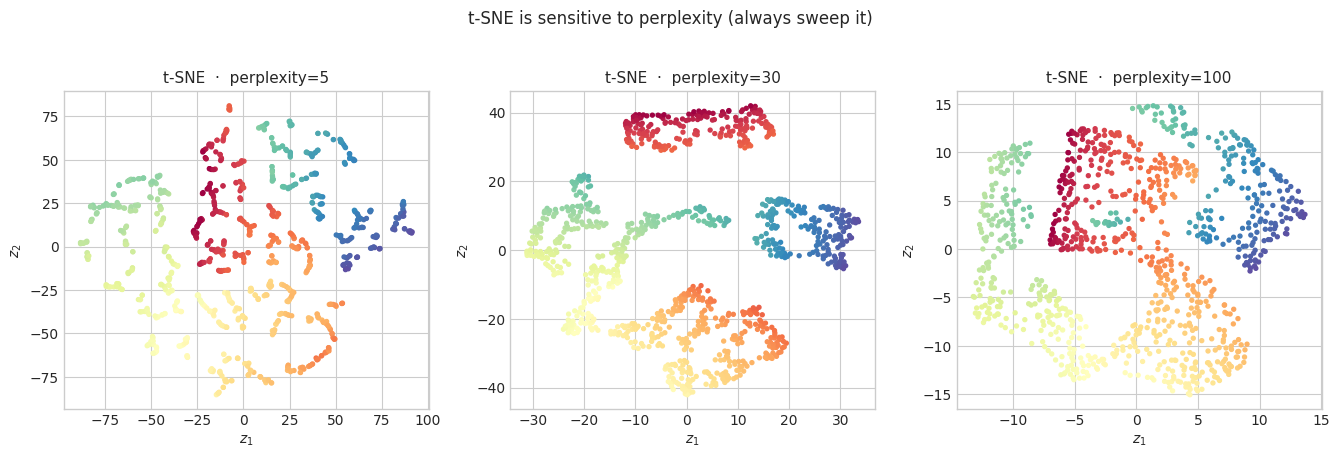

In [11]:
# Apply t-SNE at three perplexities — illustrate sensitivity (PML Fig. 20.42)
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.4))
for ax, perp in zip(axes, [5, 30, 100]):
    Z = TSNE(n_components=2, perplexity=perp, random_state=0,
             init='pca', learning_rate='auto').fit_transform(X_swiss)
    ax.scatter(Z[:, 0], Z[:, 1], c=t_swiss, cmap='Spectral', s=8)
    ax.set_title(f't-SNE  ·  perplexity={perp}', fontsize=11)
    ax.set_xlabel('$z_1$'); ax.set_ylabel('$z_2$')
plt.suptitle('t-SNE is sensitive to perplexity (always sweep it)', fontsize=12, y=1.03)
plt.tight_layout(); plt.show()

## 11. Putting It All Together: the Cell-Cycle Ring

So far we tested every method on the Swiss roll. Now apply them to the **64-d cell-cycle ring** and look for the same kind of unrolling. The expected result: a thin closed loop coloured smoothly by phase $\theta$. The radial coordinate $r$ is a second latent — methods that capture both axes will show colour bands radiating outward.

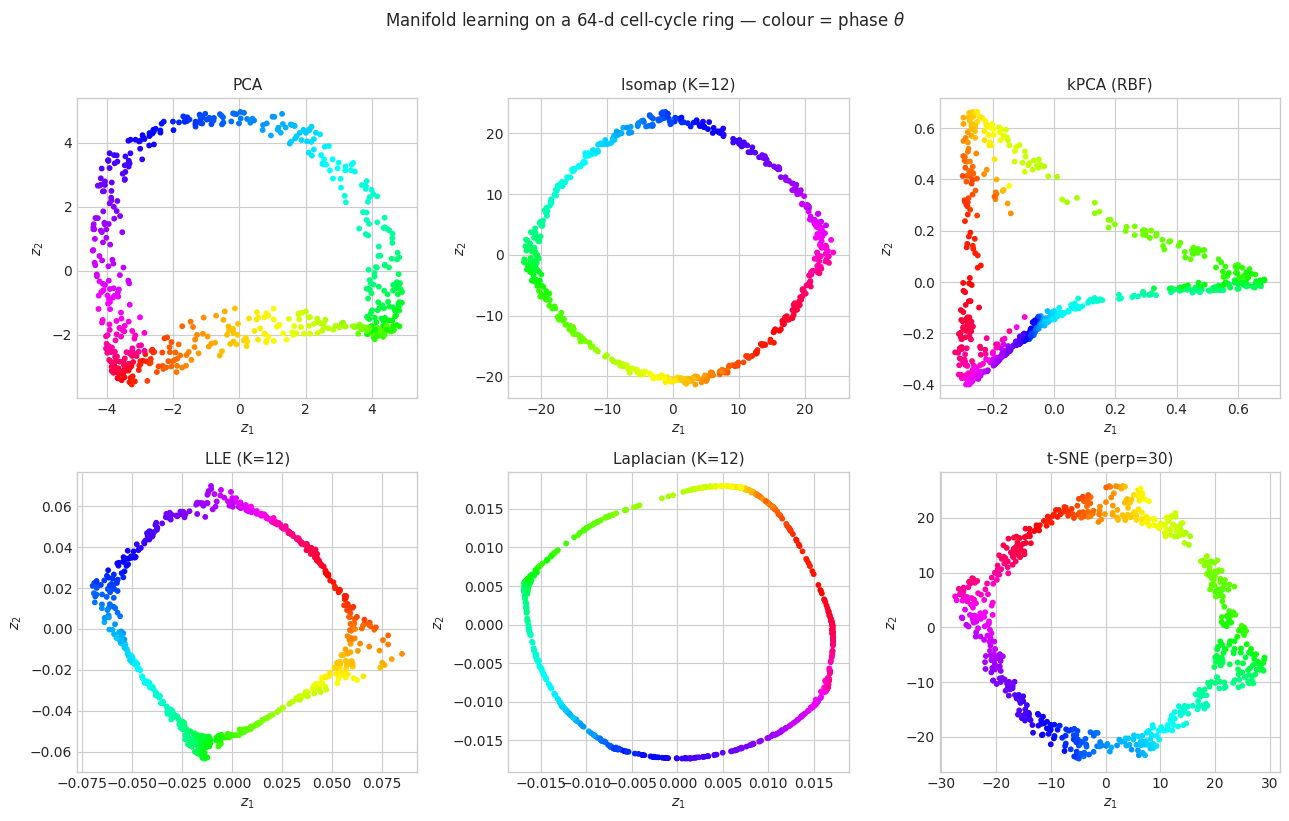

In [12]:
# Run every method on the cell ring
from sklearn.preprocessing import StandardScaler
Xc = StandardScaler().fit_transform(X_cell)

results = {}
results['PCA']               = pca_2d(X_cell)
results['Isomap (K=12)']     = Isomap(n_neighbors=12, n_components=2).fit_transform(Xc)
results['kPCA (RBF)']        = KernelPCA(n_components=2, kernel='rbf', gamma=0.05).fit_transform(Xc)
results['LLE (K=12)']        = LocallyLinearEmbedding(n_neighbors=12, n_components=2,
                                                       random_state=0).fit_transform(Xc)
results['Laplacian (K=12)']  = SpectralEmbedding(n_neighbors=12, n_components=2,
                                                  random_state=0,
                                                  affinity='nearest_neighbors').fit_transform(Xc)
results['t-SNE (perp=30)']   = TSNE(n_components=2, perplexity=30, random_state=0,
                                     init='pca', learning_rate='auto').fit_transform(Xc)

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for ax, (name, Z) in zip(axes.flat, results.items()):
    ax.scatter(Z[:, 0], Z[:, 1], c=theta_cell, cmap='hsv', s=10)
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('$z_1$'); ax.set_ylabel('$z_2$')
plt.suptitle('Manifold learning on a 64-d cell-cycle ring — colour = phase $\\theta$',
             fontsize=12, y=1.02)
plt.tight_layout(); plt.show()

**Reading the panel.**

- **PCA** linearly projects the 64-d ring; the result *looks* circular because the ring is the dominant variance source, but neighbour distances are distorted by the ambient embedding.
- **Isomap** preserves geodesic distance — the ring opens into a clean thick band whose horizontal axis tracks $\theta$ smoothly.
- **kPCA-RBF** distorts the ring into a curved blob — RBF kernels don't naturally unroll geometry.
- **LLE** preserves local structure but can squash global scale (no global metric in its objective).
- **Laplacian eigenmaps** also unroll the loop nicely but tend to compress the radial axis.
- **t-SNE** prioritises *cluster separation*; on a continuous ring it can artificially fragment the manifold into chunks at low perplexity.

For trajectory inference (e.g. reading off cell-cycle phase from scRNA-seq), Isomap and Laplacian eigenmaps are the natural choices; for cluster discovery (e.g. spotting cell types), t-SNE / UMAP are more popular.

## Summary

- A **manifold** is locally Euclidean and globally curved. The **manifold hypothesis** says natural high-dim data lies on or near one of low intrinsic dimension.
- **Classical MDS = PCA**: both flatten the data via the top eigenvectors of the centred Gram matrix.
- **Metric / non-metric MDS** generalise by minimising a stress on arbitrary dissimilarities; **Sammon mapping** reweights stress to emphasise local structure.
- **Isomap** replaces ambient distance with **geodesic distance on a kNN graph** before running classical MDS — the canonical fix for manifolds like the Swiss roll. Sensitive to short-circuit edges in noisy data.
- **Kernel PCA** is non-linear PCA via the kernel trick. With RBF kernels it tends to *expand* rather than compress, so it's not a great manifold learner on its own.
- **MVU** fixes kPCA by demanding that kNN distances be Euclidean — formulated as an SDP. Principled but expensive.
- **LLE** preserves local **barycentric coordinates** of each point in its neighbourhood; sparse eigenproblem; robust to noise.
- **Laplacian eigenmaps** find embeddings that are smooth on the kNN graph by solving the generalised eigenproblem $\mathbf{L}\mathbf{z} = \lambda \mathbf{D}\mathbf{z}$. The graph Laplacian $\mathbf{L} = \mathbf{D} - \mathbf{W}$ is the discrete derivative operator on the graph.
- **t-SNE** turns high-dim distances into conditional probabilities and matches them in low-dim with a heavy-tailed Cauchy. Excellent for visualisation, sensitive to perplexity, lossy for global structure. **UMAP** is its faster cousin with better global preservation.

This positions us for §20.5 (word embeddings), where the same spectral / probabilistic ideas reappear in the discrete setting of words and contexts.
